# QeVAE

Reimplements the core model from [Anantha-Rao12/Quantum-enhanced-variational-autoencoder](https://github.com/Anantha-Rao12/Quantum-enhanced-variational-autoencoder)
(the QeVAE of *"Learning hard distributions with quantum-enhanced Variational Autoencoders"*,
[arXiv:2305.01592](https://arxiv.org/abs/2305.01592)), mirroring the structure of `vae.ipynb` /
`svae.ipynb` / `qvae.ipynb` (data → model → train → sample → reconstructions → interpolations).

Unlike the fully-quantum autoencoder in `qvae.ipynb` (gersteinlab/QVAE — unitary encoder, trash-qubit
bottleneck, unitary decoder, all on density matrices), the QeVAE is a **hybrid classical–quantum VAE
that learns a probability distribution over measurement bitstrings**. A *classical* neural-network
encoder maps a measurement vector to a Gaussian latent; a linear preprocessor turns a latent sample
into circuit angles; and a *quantum* parameterized circuit decoder outputs a full probability
distribution over the `2^n` computational-basis bitstrings. The training signal is the negative
log-likelihood the decoder assigns to the data, plus the usual KL-to-standard-normal.

The official repo (`Sourcecode/QeVAE.py`, `Model_learndist.py`, `Auxillary_functions.py`, `main.py`)
is a Qiskit 0.x / `qiskit-machine-learning` research script: the decoder is a `CircuitQNN` (a
`ZFeatureMap` feature map + a `TwoLocal` `ry`/`rx`/`cx` ansatz) wrapped in a `TorchConnector` and run
on the `qasm_simulator`, trained with two Adam optimizers (one classical, one quantum via
parameter-shift), tied to its own 4-/8-qubit quantum-state datasets and a file-based CLI. It is not
pip-installable against current Qiskit and predates this survey's MNIST/PyTorch baseline, so instead
of importing it directly this notebook ports its load-bearing pieces — the classical
encoder / reparameterization / linear preprocessor (`Model_learndist.py::QeVAE_model`), the
`ZFeatureMap` + `TwoLocal` circuit decoder (`Model_learndist.py::create_qnn`), and the
NLL-reconstruction + KL objective (`QeVAE.py::QeVAE.train`) — as plain `torch` ops, wired into the
same MNIST pipeline used elsewhere in this survey. The decoder circuit is simulated as a
**differentiable batched statevector** (`|<b|psi>|^2` reproduces the `CircuitQNN` output
probabilities in the shot→∞ limit), so — as in `qvae.ipynb` — we train the whole thing with a single
Adam over autograd gradients instead of the original parameter-shift `CircuitQNN`, a practical swap
that leaves the model's math unchanged.

In [1]:
import math
import torch
import torch.nn as nn
import torchvision.datasets as datasets

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float64)  # statevector/gate math is numerically sensitive

## Data

Same MNIST split used by `vae.ipynb`, but — since the QeVAE learns a *probability distribution over
bitstrings* rather than pixel intensities or amplitudes — each image is turned into a distribution
over the `2^n` computational-basis states. Simulating dense quantum circuits is exponential in qubit
count, so, matching the original repo's small 4-/8-qubit inputs and mirroring `qvae.ipynb`, we
downsample each 28x28 image to 8x8 = 64 = 2^6 pixels (`n_qubit=6`) and L1-normalize each flattened
image so it sums to 1. A normalized image `p_x` is then a valid distribution over the 64 bitstrings;
reshaping it back to 8x8 recovers the picture (this is how the decoder's output is read as an image
too).

The QeVAE encoder consumes a length-`n` measurement vector (`Linear(n_qubit, 8)` in
`QeVAE_model`). The faithful per-image analogue of "a measurement of the state" here is the vector of
**per-qubit marginals** — `P(qubit i = 1)` under `p_x`, i.e. the expected value of each single-qubit
measurement — a length-`n_qubit` summary that gives every image a distinct encoder input while
keeping the encoder's ported input dimension exactly as in the repo.

In [2]:
mnist_trainset = datasets.MNIST(root='../../data', train=True, download=True, transform=None)

n_qubit = 6
res = 2 ** (n_qubit // 2)   # 8x8 = 64 = 2^6
n_states = 2 ** n_qubit

def to_distributions(images):
    x = images.reshape(-1, 1, 28, 28).double() / 255.
    x = nn.functional.adaptive_avg_pool2d(x, (res, res)).reshape(-1, res * res)
    x = x + 1e-6  # avoid an exact all-zero (unnormalizable) distribution
    return x / x.sum(dim=1, keepdim=True)  # L1-normalize -> distribution over 2^n bitstrings

# bit_table[i, b] = i-th bit (qubit i, MSB-first) of basis index b; used to read off per-qubit marginals
bit_table = torch.tensor(
    [[(b >> (n_qubit - 1 - i)) & 1 for b in range(n_states)] for i in range(n_qubit)],
    dtype=torch.float64)

def to_marginals(dist):
    return dist @ bit_table.t()  # (B, n_qubit): P(qubit i = 1), the encoder's measurement input

train_dist = to_distributions(mnist_trainset.data[:-10000])
eval_dist = to_distributions(mnist_trainset.data[-10000:])
train_marg = to_marginals(train_dist)
eval_marg = to_marginals(eval_dist)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.0MB/s]


## Quantum-circuit decoder (statevector)

Ported from `Model_learndist.py::create_qnn`. The decoder is a `ZFeatureMap` that embeds the
preprocessed latent as single-qubit rotation angles, followed by a `TwoLocal` variational ansatz
(`rotation_blocks=["ry","rx"]`, `entanglement_blocks="cx"`, linear entanglement). The original builds
this with Qiskit and evaluates it as a `CircuitQNN` on the `qasm_simulator`; here we simulate it as a
batched statevector starting from `|0...0>`, applying each gate by contracting the relevant qubit
axis, and read the output distribution as `|<b|psi>|^2` — exactly the probabilities the `CircuitQNN`
returns, but fully differentiable so autograd (not parameter-shift) supplies the gradients.

In [3]:
def apply_1q(psi, gate, q, n):
    """Apply a single-qubit gate to qubit q of a batched statevector.

    psi: (B, 2^n) complex. gate: (2, 2) shared across the batch, or (B, 2, 2) per-sample
    (used for the data-dependent feature-map rotations). Contracts the size-2 axis for qubit q.
    """
    b = psi.size(0)
    left, right = 2 ** q, 2 ** (n - q - 1)
    psi = psi.reshape(b, left, 2, right)
    if gate.dim() == 2:
        out = torch.einsum('ij,bljr->blir', gate, psi)
    else:
        out = torch.einsum('bij,bljr->blir', gate, psi)
    return out.reshape(b, -1)

# CX on the 4-dim (control, target) block, control = high bit: |10>->|11>, |11>->|10>
CX = torch.tensor([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=torch.complex128)

def apply_cx(psi, ctrl, tgt, n):
    """CX on adjacent qubits with ctrl < tgt (linear entanglement)."""
    b = psi.size(0)
    left, right = 2 ** ctrl, 2 ** (n - tgt - 1)
    psi = psi.reshape(b, left, 4, right)
    out = torch.einsum('ij,bljr->blir', CX.to(psi.device), psi)
    return out.reshape(b, -1)

H = torch.tensor([[1, 1], [1, -1]], dtype=torch.complex128) / math.sqrt(2)

def phase_gate(theta):
    """diag(1, e^{i*theta}), batched over theta: (B,) -> (B, 2, 2)."""
    b = theta.size(0)
    g = torch.zeros(b, 2, 2, dtype=torch.complex128, device=theta.device)
    g[:, 0, 0] = 1.0
    g[:, 1, 1] = torch.exp(1j * theta)
    return g

def ry_gate(theta):
    c, s = torch.cos(theta / 2), torch.sin(theta / 2)
    return torch.stack([torch.stack([c, -s]), torch.stack([s, c])]).to(torch.complex128)

def rx_gate(theta):
    c = torch.cos(theta / 2).to(torch.complex128)
    s = torch.sin(theta / 2).to(torch.complex128)
    return torch.stack([torch.stack([c, -1j * s]), torch.stack([-1j * s, c])])

def z_feature_map(psi, x, n, reps):
    """ZFeatureMap: `reps` blocks of [H on every qubit, P(2*x_i) on qubit i]. x: (B, n) angles."""
    for _ in range(reps):
        for q in range(n):
            psi = apply_1q(psi, H.to(psi.device), q, n)
        for q in range(n):
            psi = apply_1q(psi, phase_gate(2.0 * x[:, q]), q, n)
    return psi

def two_local(psi, theta, n, reps):
    """TwoLocal ry/rx + linear cx. `reps` entangling layers, `reps + 1` rotation layers
    (2*n params each: ry on every qubit then rx on every qubit)."""
    idx = 0
    for r in range(reps + 1):
        for q in range(n):
            psi = apply_1q(psi, ry_gate(theta[idx]), q, n); idx += 1
        for q in range(n):
            psi = apply_1q(psi, rx_gate(theta[idx]), q, n); idx += 1
        if r < reps:
            for q in range(n - 1):
                psi = apply_cx(psi, q, q + 1, n)
    return psi

def num_ansatz_params(n, reps):
    return 2 * n * (reps + 1)

def decoder_distribution(angles, theta, n, fm_reps, ansatz_reps):
    """angles: (B, n) preprocessed input -> (B, 2^n) probability distribution over bitstrings."""
    b = angles.size(0)
    psi = torch.zeros(b, 2 ** n, dtype=torch.complex128, device=angles.device)
    psi[:, 0] = 1.0  # |0...0>
    psi = z_feature_map(psi, angles, n, fm_reps)
    psi = two_local(psi, theta, n, ansatz_reps)
    return psi.abs() ** 2

## Model

Ported from `Model_learndist.py::QeVAE_model`. A classical encoder (`Linear(n_qubit, 8)` → LeakyReLU →
`Linear(8, 7)` → LeakyReLU) feeds two heads `z_mean` / `z_log_var`; a latent is drawn by the
reparameterization trick; a linear `preprocessor` (small-normal weights, zero bias, exactly as in the
repo) maps the latent to the `n_qubit` circuit input angles; and the quantum decoder above turns those
angles into a distribution over the `2^n` bitstrings. The only trainable *quantum* parameters are the
`TwoLocal` ansatz weights (`decoder_theta`), which stand in for the repo's `TorchConnector` weights.

In [4]:
class QeVAE(nn.Module):
    def __init__(self, n_qubit=6, latent_dim=4, fm_reps=2, ansatz_reps=2):
        super().__init__()
        self.n_qubit = n_qubit
        self.latent_dim = latent_dim
        self.fm_reps = fm_reps
        self.ansatz_reps = ansatz_reps

        self.encoder = nn.Sequential(
            nn.Linear(n_qubit, 8), nn.LeakyReLU(0.01),
            nn.Linear(8, 7), nn.LeakyReLU(0.01))
        self.z_mean = nn.Linear(7, latent_dim)
        self.z_log_var = nn.Linear(7, latent_dim)

        self.preprocessor = nn.Linear(latent_dim, n_qubit)
        nn.init.normal_(self.preprocessor.weight, mean=0, std=0.01)
        nn.init.constant_(self.preprocessor.bias, val=0)

        self.decoder_theta = nn.Parameter(0.1 * torch.randn(num_ansatz_params(n_qubit, ansatz_reps)))

    def reparameterize(self, z_mean, z_log_var):
        eps = torch.randn_like(z_mean)
        return z_mean + eps * torch.exp(z_log_var / 2.)

    def encode_mean(self, x):
        """Deterministic latent (the posterior mean) for reconstruction/interpolation."""
        return self.z_mean(self.encoder(x))

    def decode(self, z):
        angles = self.preprocessor(z)  # (B, n_qubit) real rotation angles
        return decoder_distribution(angles, self.decoder_theta,
                                    self.n_qubit, self.fm_reps, self.ansatz_reps)

    def forward(self, x):
        h = self.encoder(x)
        z_mean, z_log_var = self.z_mean(h), self.z_log_var(h)
        z = self.reparameterize(z_mean, z_log_var)
        return self.decode(z), z_mean, z_log_var

## Objective: negative log-likelihood + KL

Ported from `QeVAE.py::QeVAE.train`. The repo's reconstruction term is the NLL the decoder assigns to
the single input bitstring, `-log q(b_data)` (with its smoothing `(q + 2^-18) / (1 + 2^-18 * 2^n)` to
keep the log finite). Since each MNIST image here is a *distribution* `p_x` over bitstrings rather than
one sample, the faithful batched generalization is the cross-entropy `-Σ_b p_x(b) log q(b)`, which is
exactly the expectation of the repo's per-sample loss over `b ~ p_x` (and reduces to it when `p_x` is a
one-hot). The KL term is the repo's `-0.5 * Σ (1 + logσ² - μ² - σ²)`; `beta` is linearly annealed from
0 to 1, matching the annealing used across this survey.

In [5]:
def reconstruction_loss(recon, target):
    smoothed = (recon + 2 ** -18) / (1 + 2 ** -18 * recon.size(-1))
    return -(target * torch.log(smoothed)).sum(-1).mean()

def kl_divergence(z_mean, z_log_var):
    kl = -0.5 * torch.sum(1 + z_log_var - z_mean ** 2 - torch.exp(z_log_var), dim=-1)
    return kl.mean()

## Training

Batched over the bitstring distributions built from the downsampled images.
Simulating the decoder circuit gate-by-gate is the dominant cost and is roughly independent of batch
size, so — as in `qvae.ipynb` — more steps matters more than a bigger batch. MNIST is much larger than
the original repo's few-thousand-row quantum-state datasets, so instead of iterating over all 50000
images each epoch, every "epoch" draws one fresh random subset of `steps_per_epoch * batch_size`
images. Increase `steps_per_epoch` / `num_epochs` for a better-trained model once you've confirmed the
loss is going down.

In [6]:
model = QeVAE(n_qubit=n_qubit, latent_dim=4, fm_reps=2, ansatz_reps=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

num_epochs = 5        # Change this to train the model a bit more
steps_per_epoch = 100  # Change this to train on more data per epoch
batch_size = 32
beta_max = 1.0
log_every = 10

train_p = train_dist.to(device)
train_m = train_marg.to(device)

for epoch in range(num_epochs):
    epoch_loss = 0.0
    for step in range(steps_per_epoch):
        idx = torch.randint(0, len(train_p), (batch_size,), device=device)
        target = train_p[idx]
        enc_in = train_m[idx]

        progress = (epoch * steps_per_epoch + step) / (num_epochs * steps_per_epoch)
        beta = min(beta_max, progress * 2)

        recon, z_mean, z_log_var = model(enc_in)
        recon_l = reconstruction_loss(recon, target)
        kl_l = kl_divergence(z_mean, z_log_var)
        loss = recon_l + beta * kl_l

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        if (step + 1) % log_every == 0:
            print(f"  epoch {epoch + 1}/{num_epochs}  step {step + 1}/{steps_per_epoch}  "
                  f"recon_loss={recon_l.item():.4f}  kl={kl_l.item():.4f}")

    print(f"epoch {epoch + 1}/{num_epochs}  avg loss={epoch_loss / steps_per_epoch:.4f}")

  epoch 1/5  step 10/100  recon_loss=7.8923  kl=0.4270
  epoch 1/5  step 20/100  recon_loss=5.5051  kl=1.8407
  epoch 1/5  step 30/100  recon_loss=4.6459  kl=1.8448
  epoch 1/5  step 40/100  recon_loss=4.3625  kl=1.2415
  epoch 1/5  step 50/100  recon_loss=4.1149  kl=1.2322
  epoch 1/5  step 60/100  recon_loss=3.9466  kl=0.9874
  epoch 1/5  step 70/100  recon_loss=4.0687  kl=0.6563
  epoch 1/5  step 80/100  recon_loss=3.9455  kl=0.5084
  epoch 1/5  step 90/100  recon_loss=3.8525  kl=0.2970
  epoch 1/5  step 100/100  recon_loss=3.8443  kl=0.1760
epoch 1/5  avg loss=5.0455
  epoch 2/5  step 10/100  recon_loss=3.7391  kl=0.1221
  epoch 2/5  step 20/100  recon_loss=3.6696  kl=0.0674
  epoch 2/5  step 30/100  recon_loss=3.6952  kl=0.0404
  epoch 2/5  step 40/100  recon_loss=3.6423  kl=0.0097
  epoch 2/5  step 50/100  recon_loss=3.5396  kl=0.0015
  epoch 2/5  step 60/100  recon_loss=3.4641  kl=0.0011
  epoch 2/5  step 70/100  recon_loss=3.5013  kl=0.0002
  epoch 2/5  step 80/100  recon_loss=

## Visualizing samples

Mirrors `sample()` / `Decoder_distribution` in the repo: draw a latent from the standard-normal prior,
push it through the preprocessor and quantum decoder, and read the resulting `2^n` distribution back
as an 8x8 image.

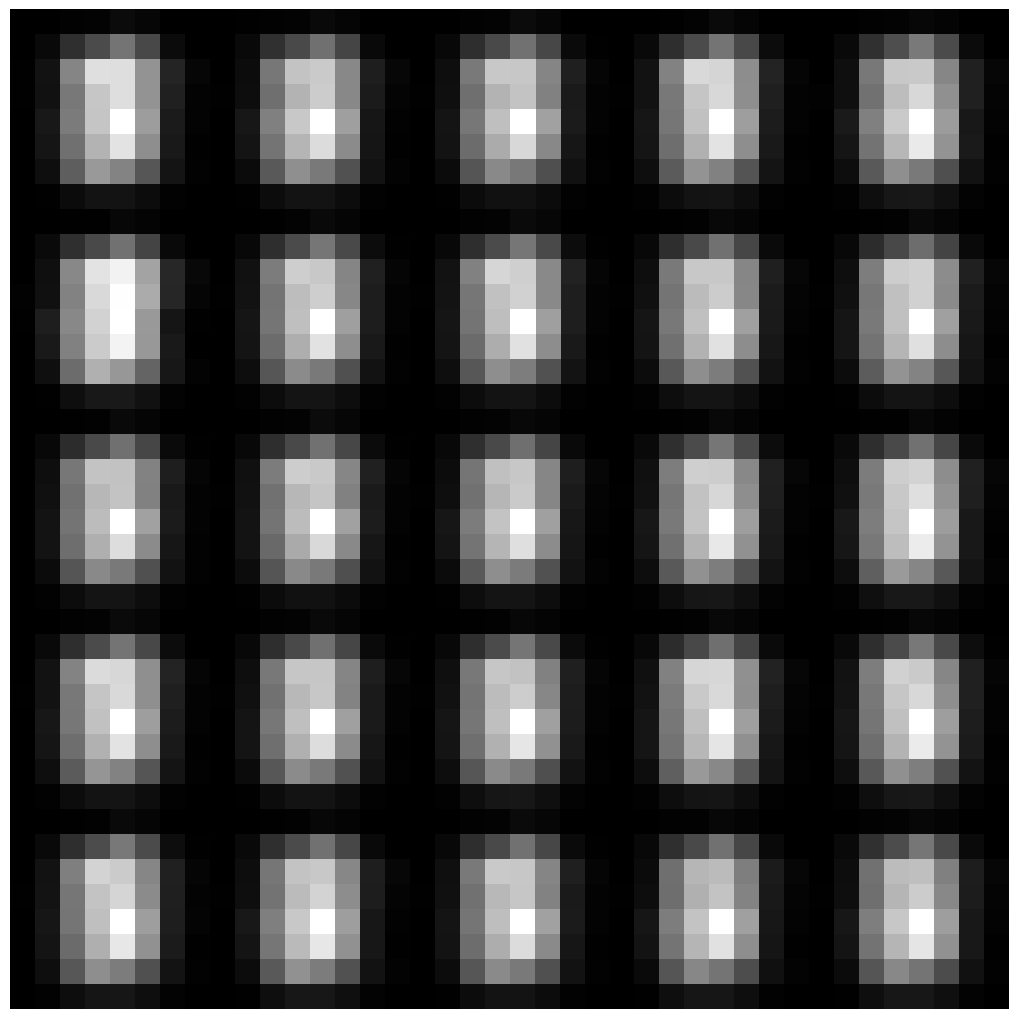

In [7]:
import matplotlib.pyplot as plt

def dist_to_image(prob):
    prob = prob.real.clamp(min=0)
    prob = prob / prob.sum(dim=-1, keepdim=True)
    return prob.reshape(-1, res, res)

model.eval()
with torch.no_grad():
    z = torch.randn(25, model.latent_dim, device=device)
    gen_data = dist_to_image(model.decode(z)).cpu()

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(gen_data[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

## Visualizing reconstructions

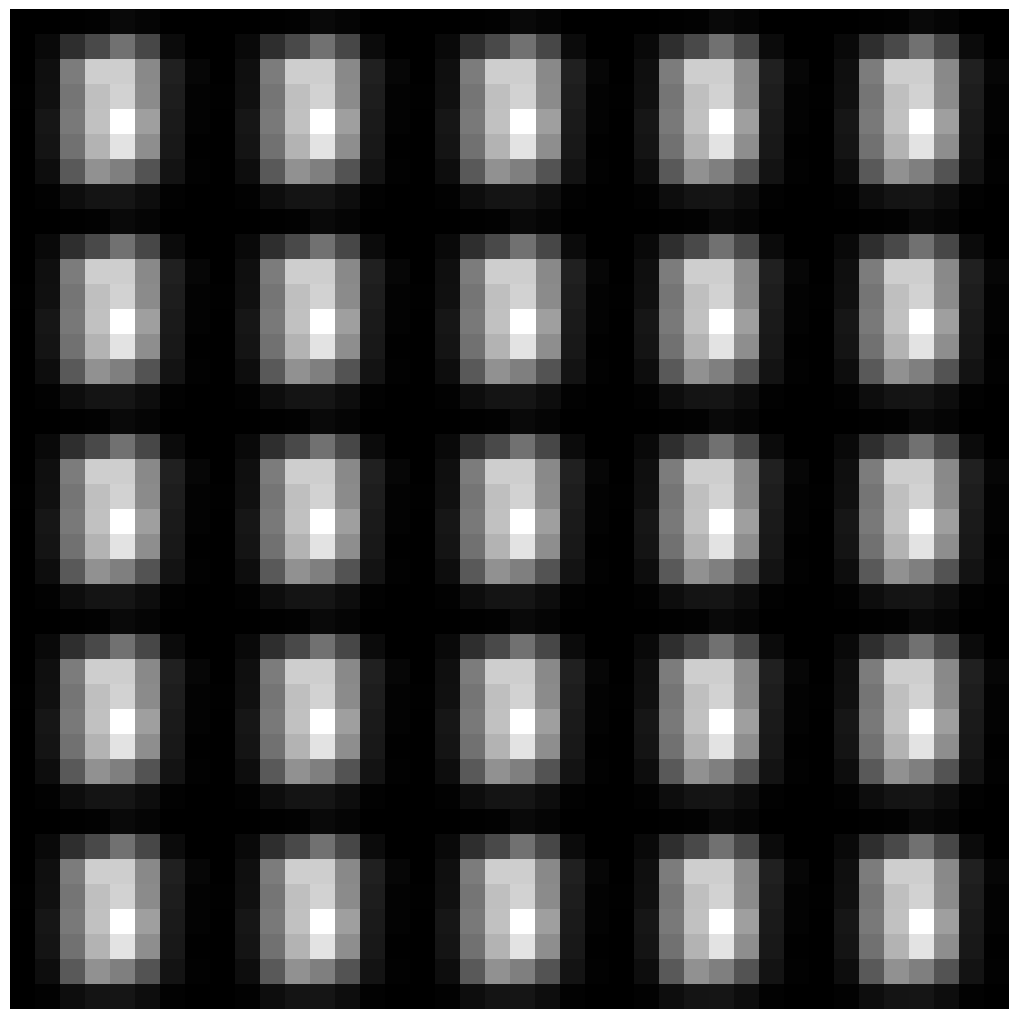

In [8]:
eval_in = eval_marg[:25].to(device)
with torch.no_grad():
    z = model.encode_mean(eval_in)
    reconstructions = dist_to_image(model.decode(z)).cpu()

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(reconstructions[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

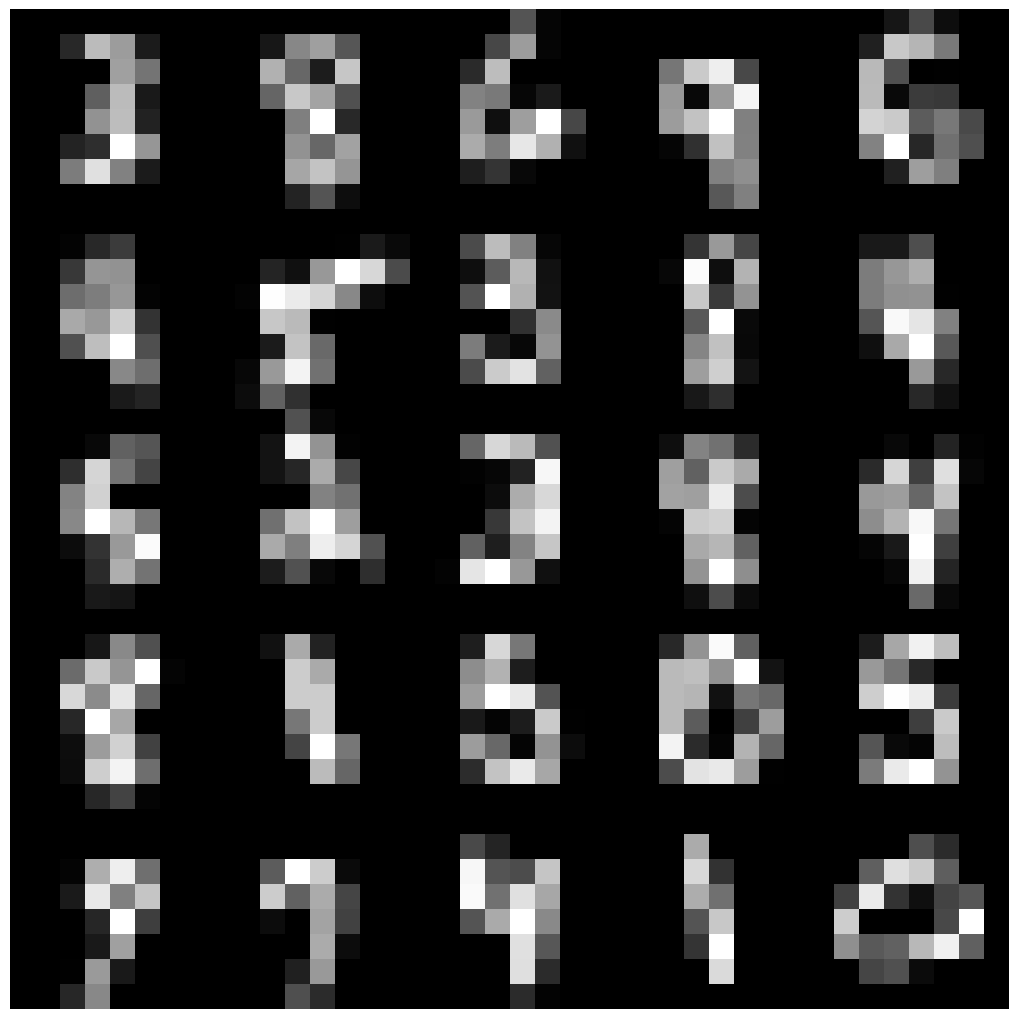

In [9]:
# show the true data (the target bitstring distributions, reshaped to images)
true_images = eval_dist[:25].reshape(-1, res, res)

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(true_images[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

## Visualizing interpolations

The QeVAE latent is an ordinary Gaussian vector (unlike the density-matrix latent in `qvae.ipynb`), so
interpolation is the same linear walk in latent space used by `vae.ipynb`: encode two batches of images
to their posterior means and decode `(1-a) z1 + a z2` for `a` from 0 to 1.

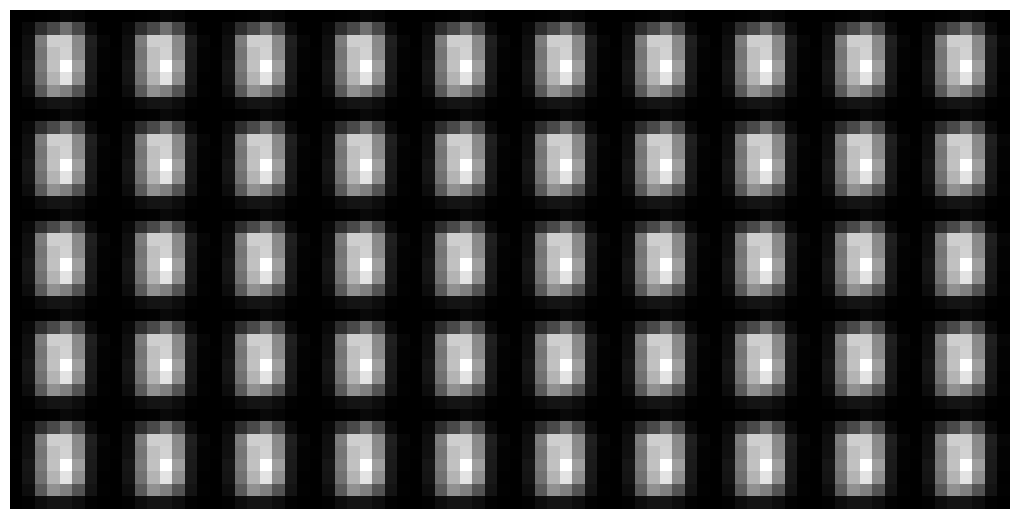

In [10]:
x1 = eval_marg[:5].to(device)
x2 = eval_marg[5:10].to(device)

with torch.no_grad():
    z1 = model.encode_mean(x1)
    z2 = model.encode_mean(x2)

    granularity = 10
    alphas = torch.linspace(0, 1, granularity, device=device)
    frames = [model.decode((1 - a) * z1 + a * z2) for a in alphas]
    interpolations = torch.stack(frames)  # (granularity, 5, 2^n)
    interpolations = dist_to_image(interpolations.reshape(-1, n_states))
    interpolations = interpolations.reshape(granularity, 5, res, res).permute(1, 0, 2, 3).cpu()

fig, axes = plt.subplots(nrows=5, ncols=10, figsize=(10, 5))
for i in range(5):
    for j in range(10):
        axes[i][j].imshow(interpolations[i, j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)